# Guideline

Input: 
1. Very-Preterm_UBC-Trajectory_Neonatal_SkullStripped3DT1_V02_PMA_at_MRI.tsv: 
study_id | pma_mri_v02 (postmentural weeks)	| skullstripped_3D_T1_v02
1        | 39.43                            | bc0001_20010101_150730_4_mri_3DT1_V02_stripped.nii
2. T1w images for :
For UBC-3D, only T1w  
each row in Very-Preterm_UBC-Trajectory_Neonatal_SkullStripped3DT1_V02_PMA_at_MRI.xlsx: 


Note:
For now, UBC-3D has both preterm and full term baby, so we just try to warp them into 0 and 1 month tpl at first


Process:
1. skull-stripping, already mannually finished by sickkids fellow
2. N4 bias corection
3. direct warp 

Quanlity Control: 
1. visually check (by Jessie)
2. correlation with tpl
3. cerebellar mask alignment

# Next Steps

1. **Re-run iBEAT 2.0 on the UBC cohort** — timeline to be confirmed with Jessie.
2. **Extend registration: 8-year subjects to adult template.** 
3. **Integrate into the N-model** — to be discussed with Alice.
4. **Preterm care cohort analysis** — repeat the pipeline as applied to the UBC cohort.  

SickKids HPC server:

Conda:
srun -N 1 -c 1 --mem=16g --time 24:00:00 --tmp 10g --pty bash
cd /hpf/largeprojects/smiller/projects/uwo_rcp/
conda activate /hpf/largeprojects/smiller/tools/rcp_pipeline/conda_environments/rcp_env/

Login:
smb://carbon14.ccm.sickkids.ca for folder mount
ssh ywang6725@slogin.ccm.sickkids.ca
/hpf/largeprojects/smiller/projects/uwo_rcp/

VScode:
https://hpc.ccm.sickkids.ca
ondemons.ccm.sickkids.ca

In [5]:
import pandas as pd
import os
import sys
base_dir  = "/hpf/largeprojects/smiller/projects/uwo_rcp"
Info_dir  = f"{base_dir}/Info"
pipel_dir = f"{base_dir}/Output"
tpl_root  = f"{base_dir}/NeonatalNormalization/templates"
sys.path.append(f"{base_dir}/NeonatalNormalization/Script")
from tpl_xfm_build import multimodal_register_pipeline

# read the Excel source
df = pd.read_excel(f"{Info_dir}/Very-Preterm_UBC-Trajectory_Neonatal_SkullStripped3DT1_V02_PMA_at_MRI.xlsx")

# change *.nii.gz -> *.nii in the filename column
df['skullstripped_3DT1_v02'] = df['skullstripped_3DT1_v02'].str.replace(r'\.nii\.gz$', '.nii', regex=True)

# write it as CSV
df.to_csv(f"{Info_dir}/Very-Preterm_UBC-Trajectory_Neonatal_SkullStripped3DT1_V02_PMA_at_MRI.csv", index=False, encoding="utf-16")

# 1. Process

## 1.1 Manually skull stripping finished
Visual QC already done

## 1.2 N4 bias correction

In [6]:
import pandas as pd
import os
import sys
import glob
base_dir  = "/hpf/largeprojects/smiller/projects/uwo_rcp"
data_dir = f"{base_dir}/Data"
Info_dir  = f"{base_dir}/Info"
pipel_dir = f"{base_dir}/Output"
tpl_root  = f"{base_dir}/NeonatalNormalization/templates"

dataset_name = "UBC_3D"
dataset_name_exp = "Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_SkullStripped_nii"
sys.path.append(f"{base_dir}/NeonatalNormalization/Script")
from tpl_xfm_build import N4_bias_correction
subs_info = pd.read_csv(f"{Info_dir}/Very-Preterm_UBC-Trajectory_Neonatal_SkullStripped3DT1_V02_PMA_at_MRI.csv", encoding="utf-16")
subs_valid = subs_info[subs_info['skullstripped_3DT1_v02'].notna()]
print(f"We have totally {len(subs_valid)} subjects")

We have totally 185 subjects


In [7]:
for _, row in subs_valid.iterrows():   # .head(10) to test
    subid = f"bc{int(row['study_id']):04d}"
    output_dir = os.path.join(pipel_dir, dataset_name, subid)
    input_name = row['skullstripped_3DT1_v02']
    input_file = os.path.join(data_dir, dataset_name_exp, input_name)

    if input_name.endswith('.nii.gz'):
        output_name = input_name[:-7] + '_N4.nii.gz'
    elif input_name.endswith('.nii'):
        output_name = input_name[:-4] + '_N4.nii.gz'
    else:
        raise ValueError(f"Not a NIfTI file: {input_name}")

    output_file = os.path.join(output_dir, output_name)


    if not os.path.exists(output_file):
        print(subid)
        print(input_file)
        print(output_file)
        N4_bias_correction(
            input_file  = input_file,
            output_file = output_file,
            slurm       = True,
        )

bc0001
/hpf/largeprojects/smiller/projects/uwo_rcp/Data/Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_SkullStripped_nii/bc0001_20010101_150730_4_mri_3DT1_V02_stripped.nii
/hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0001/bc0001_20010101_150730_4_mri_3DT1_V02_stripped_N4.nii.gz
[INFO] Submitting job: N4_bc0001
[INFO] Job script: /hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0001/log/N4_bc0001.sh
[INFO] sbatch output: Submitted batch job 29416646
[INFO] Job ID: 29416646
bc0003
/hpf/largeprojects/smiller/projects/uwo_rcp/Data/Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_SkullStripped_nii/bc0003_20010101_135647_9_mri_3DT1_V02_stripped.nii
/hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0003/bc0003_20010101_135647_9_mri_3DT1_V02_stripped_N4.nii.gz
[INFO] Submitting job: N4_bc0003
[INFO] Job script: /hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0003/log/N4_bc0003.sh
[INFO] sbatch output: Submitted batch job 29416647
[INFO] Job ID: 29416

## 1.3 Direct warp to age-specific (0 and 1M tpl)

For each subj, 2 tpls, 1 xfms, 2 warped totally

In [3]:
import pandas as pd
import os
import sys
import glob
base_dir  = "/hpf/largeprojects/smiller/projects/uwo_rcp"
data_dir = f"{base_dir}/Data"
Info_dir  = f"{base_dir}/Info"
pipel_dir = f"{base_dir}/Output"
tpl_root  = f"{base_dir}/NeonatalNormalization/templates"

dataset_name = "UBC_3D"
dataset_name_exp = "Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_SkullStripped_nii"
sys.path.append(f"{base_dir}/NeonatalNormalization/Script")
from tpl_xfm_build import multimodal_register_pipeline
subs_info = pd.read_csv(f"{Info_dir}/Very-Preterm_UBC-Trajectory_Neonatal_SkullStripped3DT1_V02_PMA_at_MRI.csv", encoding="utf-16")
subs_valid = subs_info[subs_info['skullstripped_3DT1_v02'].notna()]
print(f"We have totally {len(subs_valid)} subjects")

We have totally 185 subjects


In [ ]:
import glob
import os

xfm_mods = ['T1']
TPL_FIX_months = ["00", "01"]

for _, row in subs_valid.iterrows():   # .head(10) to test
    subid = f"bc{int(row['study_id']):04d}"
    
    # Input: N4 bias corrected T1
    output_dir  = os.path.join(pipel_dir, dataset_name, subid)
    input_name = row['skullstripped_3DT1_v02']
    if input_name.endswith('.nii.gz'):
        n4_name = input_name[:-7] + '_N4.nii.gz'
    elif input_name.endswith('.nii'):
        n4_name = input_name[:-4] + '_N4.nii.gz'
    else:
        raise ValueError(f"Not a NIfTI file: {input_name}")
    n4_file = os.path.join(output_dir, n4_name)
    input_files = {'T1': n4_file}

    # Direct Warp
    for xfm in xfm_mods:
        for TPL_FIX in TPL_FIX_months:
            # # check output file
            # output_name = f'T1_resliced_to_{TPL_FIX}Mtpl_by_direct_{xfm}_xfm.nii.gz'
            # output_file = os.path.join(output_dir, output_name)
            # if not os.path.exists(output_file):
            #     print(subid)
            #     print(output_file)
            print(f"\n=== Step 1: direct registration to {TPL_FIX}M ===")
            multimodal_register_pipeline(
                modalities   = xfm,
                input_files  = input_files,
                tpl_root     = tpl_root,
                tpl_month    = TPL_FIX,
                output_dir   = output_dir,
                steps        = [1, 2, 3, 4],
                slurm        = True,
            )


=== Step 1: direct registration to 00M ===
[INFO] Submitting job: T1_00Mtpl
[INFO] Job script: /hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0001/log/T1_00Mtpl.sh
[INFO] sbatch output: Submitted batch job 29419255
[INFO] Job ID: 29419255

=== Step 1: direct registration to 01M ===
[INFO] Submitting job: T1_01Mtpl
[INFO] Job script: /hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0001/log/T1_01Mtpl.sh
[INFO] sbatch output: Submitted batch job 29419256
[INFO] Job ID: 29419256

=== Step 1: direct registration to 00M ===
[INFO] Submitting job: T1_00Mtpl
[INFO] Job script: /hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0002/log/T1_00Mtpl.sh
[INFO] sbatch output: Submitted batch job 29419257
[INFO] Job ID: 29419257

=== Step 1: direct registration to 01M ===
[INFO] Submitting job: T1_01Mtpl
[INFO] Job script: /hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0002/log/T1_01Mtpl.sh
[INFO] sbatch output: Submitted batch job 29419258
[INFO] Job I

# 2. QC

In [17]:
# Check how many subs has output already
import os

path = "/hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D"
count = sum(1 for entry in os.scandir(path) if entry.is_dir())
print('We have finished these subjects: ')
print(count)

We have finished these subjects: 
185


## 2.1 R with tpl

In [4]:
import os
import numpy as np
import pandas as pd
import nibabel as nib
from tqdm import tqdm

base_dir = "/hpf/largeprojects/smiller/projects/uwo_rcp"
BASE     = f"{base_dir}/Output/UBC_3D"
tpl_root = f"{base_dir}/NeonatalNormalization/templates"
info_csv = f"{base_dir}/Info/Very-Preterm_UBC-Trajectory_Neonatal_SkullStripped3DT1_V02_PMA_at_MRI.csv"
qc_dir   = f"{base_dir}/NeonatalNormalization/QC_sickkids"
out_csv  = f"{qc_dir}/tpl_corr_vs_pma.csv"

os.makedirs(qc_dir, exist_ok=True)

# --- PMA table ---
info = pd.read_csv(info_csv, encoding="utf-16")
info = info[info["PMA_mri_v02"].notna()]
print(f"Subjects with PMA: {len(info)}")

# --- Templates: (template, resliced-suffix, mask) ---
templates = {
    "00M": (
        f"{tpl_root}/00Month/BCP-00M-T1.nii.gz",
        "T1_resliced_to_00Mtpl_by_direct_T1_xfm.nii.gz",
        f"{tpl_root}/00Month/BCP-00M-mask.nii.gz",
    ),
    "01M": (
        f"{tpl_root}/01Month/BCP-01M-T1.nii.gz",
        "T1_resliced_to_01Mtpl_by_direct_T1_xfm.nii.gz",
        f"{tpl_root}/01Month/BCP-01M-mask.nii.gz",
    ),
}

subjects = sorted(f for f in os.listdir(BASE) if os.path.isdir(f"{BASE}/{f}"))

records = []
for label, (tpl_path, suffix, mask_path) in templates.items():
    tpl = nib.load(tpl_path).get_fdata()

    if mask_path and os.path.exists(mask_path):
        mask = nib.load(mask_path).get_fdata() > 0
    else:
        mask = tpl > 0
    print(f"{label}: mask has {mask.sum()} voxels")

    n = 0
    for sub in tqdm(subjects):
        img_path = f"{BASE}/{sub}/{suffix}"
        if not os.path.exists(img_path):
            continue

        row = info[info["study_id"] == int(sub.replace("bc", ""))]
        if row.empty:
            continue
        age = row["PMA_mri_v02"].iloc[0]

        img_data = nib.load(img_path).get_fdata()
        if img_data.shape != tpl.shape:
            continue

        r = np.corrcoef(img_data[mask], tpl[mask])[0, 1]
        records.append({"subject": sub, "template": label, "pma": age, "corr": r})
        n += 1
    print(f"{label}: {n} subjects")

result = pd.DataFrame(records)
result.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}  ({len(result)} rows)")

Subjects with PMA: 185
00M: mask has 1143576 voxels


100%|██████████| 185/185 [01:48<00:00,  1.71it/s]


00M: 185 subjects
01M: mask has 1245812 voxels


100%|██████████| 185/185 [01:50<00:00,  1.67it/s]

01M: 185 subjects
Saved: /hpf/largeprojects/smiller/projects/uwo_rcp/NeonatalNormalization/QC_sickkids/tpl_corr_vs_pma.csv  (370 rows)


Saved figure: /hpf/largeprojects/smiller/projects/uwo_rcp/NeonatalNormalization/QC_sickkids/tpl_corr_vs_pma.pdf
Saved ranked: /hpf/largeprojects/smiller/projects/uwo_rcp/NeonatalNormalization/QC_sickkids/tpl_corr_ranked.csv


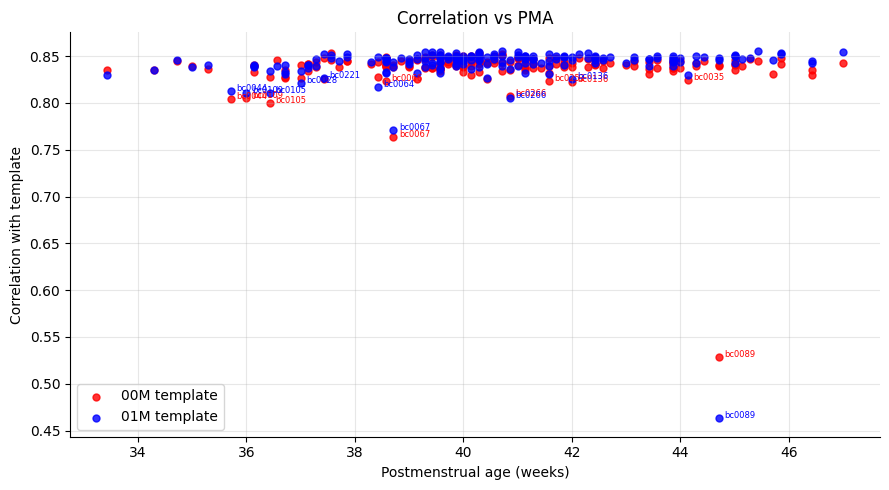

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

base_dir = "/hpf/largeprojects/smiller/projects/uwo_rcp"
qc_dir   = f"{base_dir}/NeonatalNormalization/QC_sickkids"
in_csv   = f"{qc_dir}/tpl_corr_vs_pma.csv"
out_pdf  = f"{qc_dir}/tpl_corr_vs_pma.pdf"
out_rank = f"{qc_dir}/tpl_corr_ranked.csv"

df = pd.read_csv(in_csv)
colors = {"00M": "red", "01M": "blue"}

fig, ax = plt.subplots(figsize=(9, 5))

ranked = []
for label, color in colors.items():
    sub = df[df["template"] == label].sort_values("corr")
    lowest, highest = sub.head(10), sub.tail(10)

    ax.scatter(sub["pma"], sub["corr"], s=25, alpha=0.8,
               color=color, label=f"{label} template")

    # annotate only the bottom 10
    for _, r in lowest.iterrows():
        ax.annotate(r["subject"], (r["pma"], r["corr"]),
                    fontsize=6, color=color,
                    xytext=(4, 0), textcoords="offset points")

    # collect for the ranked CSV
    lowest  = lowest.assign(template=label, rank="lowest10")
    highest = highest.assign(template=label, rank="highest10")
    ranked.append(pd.concat([lowest, highest]))

ax.set_xlabel("Postmenstrual age (weeks)")
ax.set_ylabel("Correlation with template")
ax.set_title("Correlation vs PMA")
ax.grid(True, alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="lower left")

plt.tight_layout()
fig.savefig(out_pdf)

# save ranked lists
ranked_df = pd.concat(ranked)[["template", "rank", "subject", "pma", "corr"]]
ranked_df.to_csv(out_rank, index=False)

print(f"Saved figure: {out_pdf}")
print(f"Saved ranked: {out_rank}")

## 2.2 Cereb mask dice score

In [1]:
import pandas as pd
import os
import sys
import glob
base_dir  = "/hpf/largeprojects/smiller/projects/uwo_rcp"
data_dir = f"{base_dir}/Data"
Info_dir  = f"{base_dir}/Info"
pipel_dir = f"{base_dir}/Output"
tpl_root  = f"{base_dir}/NeonatalNormalization/templates"

dataset_name = "UBC_3D"
dataset_name_exp = "Very-Preterm_UBC-Trajectory_Neonatal_3DT1_V02_SkullStripped_nii"
sys.path.append(f"{base_dir}/NeonatalNormalization/Script")
from tpl_xfm_build import T1_cereb_isolate
subs_info = pd.read_csv(f"{Info_dir}/Very-Preterm_UBC-Trajectory_Neonatal_SkullStripped3DT1_V02_PMA_at_MRI.csv", encoding="utf-16")
subs_valid = subs_info[subs_info['skullstripped_3DT1_v02'].notna()]
print(f"We have totally {len(subs_valid)} subjects")

We have totally 185 subjects


In [2]:
import glob
import os
import SUITPy as suit
import nibabel as nib
import numpy as np

for _, row in subs_valid.head(10).iterrows():   # .head(10) to test
    subid = f"bc{int(row['study_id']):04d}"
    
    # Input: N4 bias corrected T1
    output_dir  = os.path.join(pipel_dir, dataset_name, subid)
    input_name = row['skullstripped_3DT1_v02']
    if input_name.endswith('.nii.gz'):
        n4_name = input_name[:-7] + '_N4.nii.gz'
    elif input_name.endswith('.nii'):
        n4_name = input_name[:-4] + '_N4.nii.gz'
    else:
        raise ValueError(f"Not a NIfTI file: {input_name}")
    n4_file = os.path.join(output_dir, n4_name)
    T1_cereb_isolate(T1_file=n4_file, 
                     output_dir=output_dir)

    


[INFO] Submitting job: cereb_isolate
[INFO] Job script: /hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0001/log/cereb_isolate.sh
[INFO] sbatch output: Submitted batch job 29420108
[INFO] Job ID: 29420108
[INFO] Submitting job: cereb_isolate
[INFO] Job script: /hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0002/log/cereb_isolate.sh
[INFO] sbatch output: Submitted batch job 29420109
[INFO] Job ID: 29420109
[INFO] Submitting job: cereb_isolate
[INFO] Job script: /hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0003/log/cereb_isolate.sh
[INFO] sbatch output: Submitted batch job 29420110
[INFO] Job ID: 29420110
[INFO] Submitting job: cereb_isolate
[INFO] Job script: /hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0004/log/cereb_isolate.sh
[INFO] sbatch output: Submitted batch job 29420111
[INFO] Job ID: 29420111
[INFO] Submitting job: cereb_isolate
[INFO] Job script: /hpf/largeprojects/smiller/projects/uwo_rcp/Output/UBC_3D/bc0006/log/cereb_i